In [2]:
!pip install pandas-datareader

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

# All currency pairs — G10 + Asian
pairs = {
    # G10
    "USDJPY": "USDJPY=X",
    "EURUSD": "EURUSD=X",
    "GBPUSD": "GBPUSD=X",
    "AUDUSD": "AUDUSD=X",
    # Asian
    "USDHKD": "USDHKD=X",
    "USDKRW": "USDKRW=X",
    "USDSGD": "USDSGD=X",
    "USDINR": "USDINR=X",
}

# Download all pairs
fx_data = {}
for pair, ticker in pairs.items():
    df = yf.download(ticker, start="2015-01-01", end="2026-08-29", auto_adjust=True)
    df.columns = df.columns.get_level_values(0)
    fx_data[pair] = df["Close"]

# Combine into one DataFrame
fx = pd.DataFrame(fx_data)
fx = fx.ffill()  # Forward fill any missing data
print(fx.tail())
print(f"\nShape: {fx.shape}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

                USDJPY    EURUSD    GBPUSD    AUDUSD   USDHKD       USDKRW  \
Date                                                                         
2026-08-24  158.904007  1.168156  1.365355  0.717140  7.83920  1384.979980   
2026-08-25  159.139008  1.166834  1.363829  0.715482  7.83601  1380.760010   
2026-08-26  159.223007  1.167474  1.364703  0.716533  7.83804  1381.489990   
2026-08-27  159.255005  1.165488  1.359693  0.718150  7.83880  1383.489990   
2026-08-28  160.037994  1.158749  1.353748  0.719510  7.83910  1380.449951   

             USDSGD     USDINR  
Date                            
2026-08-24  1.26922  95.700302  
2026-08-25  1.26988  95.723099  
2026-08-26  1.26886  93.546097  
2026-08-27  1.27141  95.430298  
2026-08-28  1.27080  95.470398  

Shape: (3034, 8)


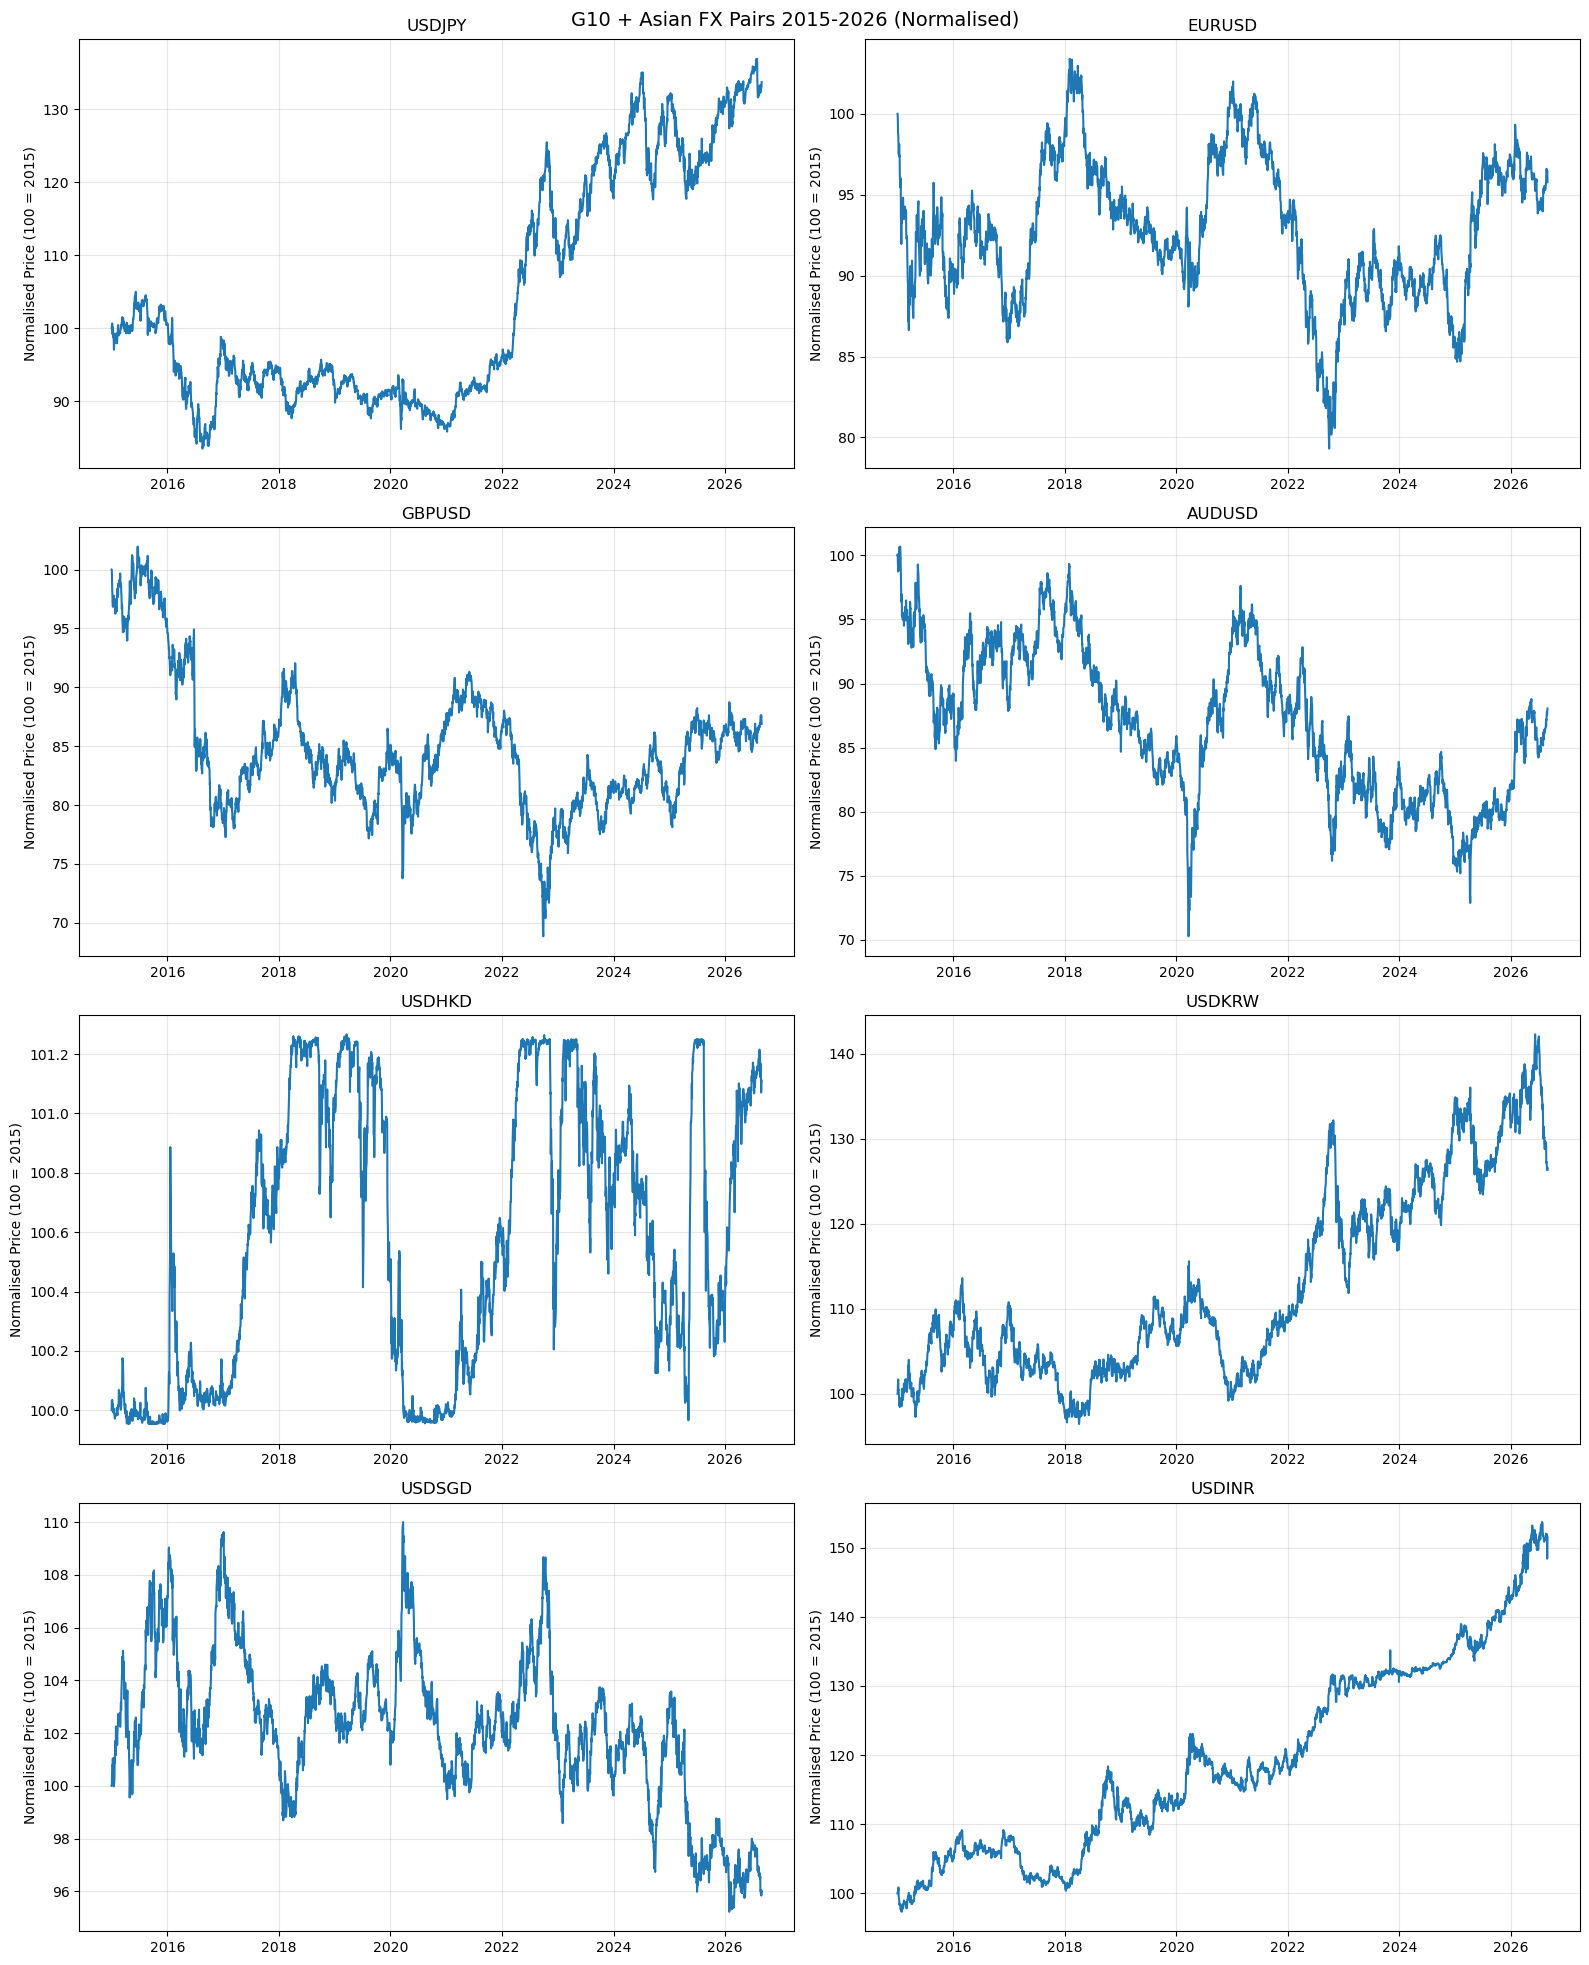

In [4]:
# Normalise all pairs to 100 at start for comparison
fx_normalised = fx / fx.iloc[0] * 100

# Plot all pairs
fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, pair in enumerate(fx.columns):
    axes[i].plot(fx_normalised[pair], label=pair)
    axes[i].set_title(pair)
    axes[i].set_ylabel("Normalised Price (100 = 2015)")
    axes[i].grid(True, alpha=0.3)

plt.suptitle("G10 + Asian FX Pairs 2015-2026 (Normalised)", fontsize=14)
plt.tight_layout()
plt.show()

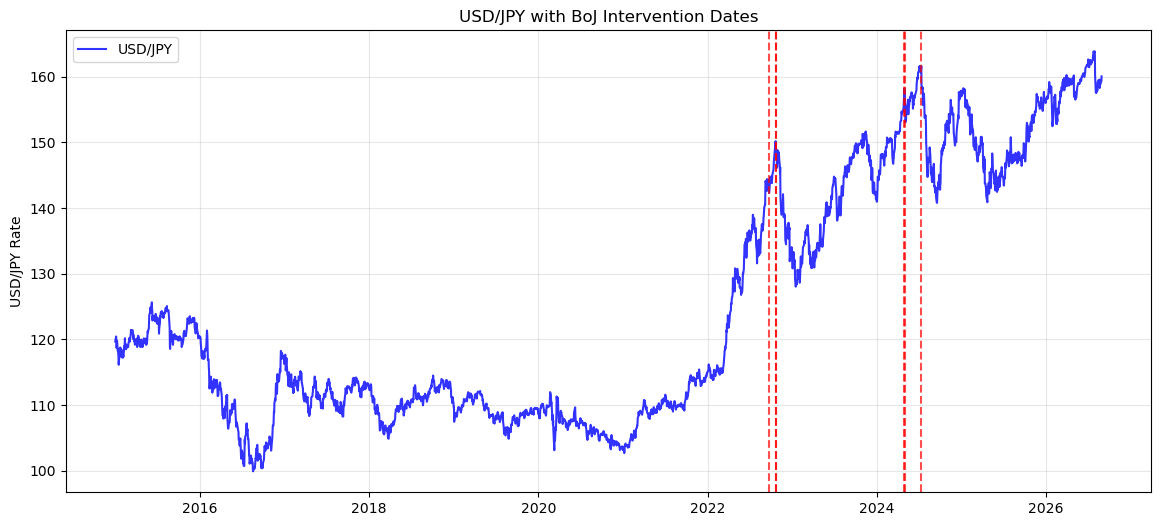

In [5]:
# BoJ Intervention dates
# Major confirmed interventions
boj_interventions = [
    "2022-09-22",  # First 2022 intervention - sold USD bought JPY
    "2022-10-21",  # Second 2022 intervention
    "2022-10-24",  # Third 2022 intervention
    "2024-04-29",  # First 2024 intervention around 160
    "2024-05-01",  # Second 2024 intervention
    "2024-07-11",  # Third 2024 intervention
]

boj_interventions = [pd.Timestamp(d) for d in boj_interventions]

# Plot USD/JPY with intervention dates marked
plt.figure(figsize=(14, 6))
plt.plot(fx["USDJPY"], label="USD/JPY", color="blue", alpha=0.8)

for date in boj_interventions:
    plt.axvline(x=date, color="red", linestyle="--", alpha=0.7, linewidth=1.5)

plt.title("USD/JPY with BoJ Intervention Dates")
plt.ylabel("USD/JPY Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

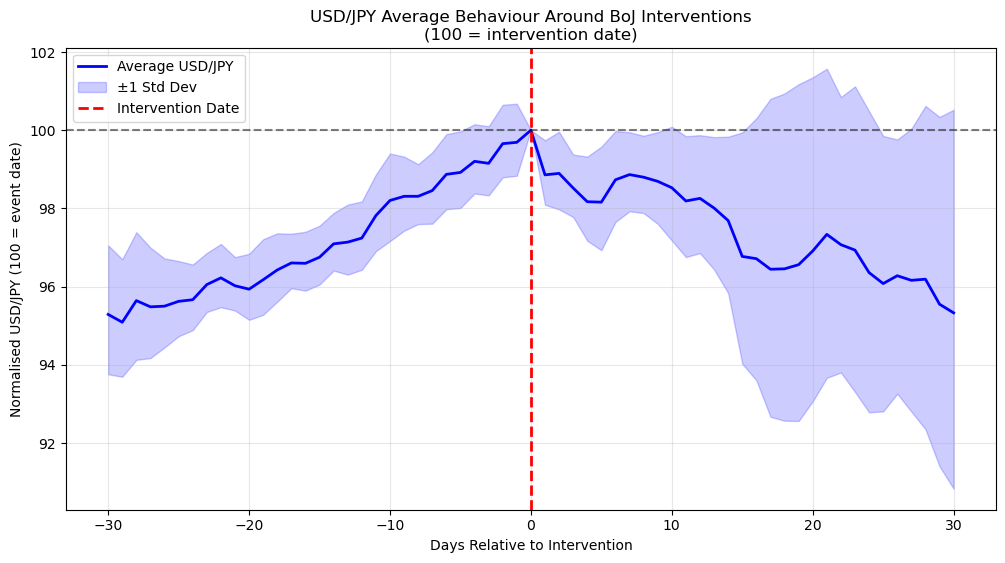

In [6]:
# Event study function
def event_study(price_series, event_dates, window=30):
    """
    For each event date, extract price returns
    in the window before and after the event.
    """
    results = []
    
    for date in event_dates:
        # Find the nearest trading day
        try:
            idx = price_series.index.get_indexer([date], method="nearest")[0]
        except:
            continue
        
        # Extract window around event
        start = max(0, idx - window)
        end = min(len(price_series), idx + window + 1)
        
        window_prices = price_series.iloc[start:end]
        
        # Normalise to 100 at event date
        event_price = price_series.iloc[idx]
        normalised = (window_prices / event_price) * 100
        
        # Reindex to days relative to event (-30 to +30)
        relative_days = list(range(-( idx - start), end - idx))
        normalised.index = relative_days[:len(normalised)]
        
        results.append(normalised)
    
    # Average across all events
    df = pd.DataFrame(results).T
    df["mean"] = df.mean(axis=1)
    df["upper"] = df.mean(axis=1) + df.std(axis=1)
    df["lower"] = df.mean(axis=1) - df.std(axis=1)
    
    return df

# Run event study on USD/JPY around BoJ interventions
usdjpy_study = event_study(fx["USDJPY"], boj_interventions, window=30)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(usdjpy_study["mean"], color="blue", label="Average USD/JPY", linewidth=2)
plt.fill_between(usdjpy_study.index,
                 usdjpy_study["lower"],
                 usdjpy_study["upper"],
                 alpha=0.2, color="blue", label="±1 Std Dev")
plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Intervention Date")
plt.axhline(y=100, color="black", linestyle="--", alpha=0.5)
plt.title("USD/JPY Average Behaviour Around BoJ Interventions\n(100 = intervention date)")
plt.xlabel("Days Relative to Intervention")
plt.ylabel("Normalised USD/JPY (100 = event date)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

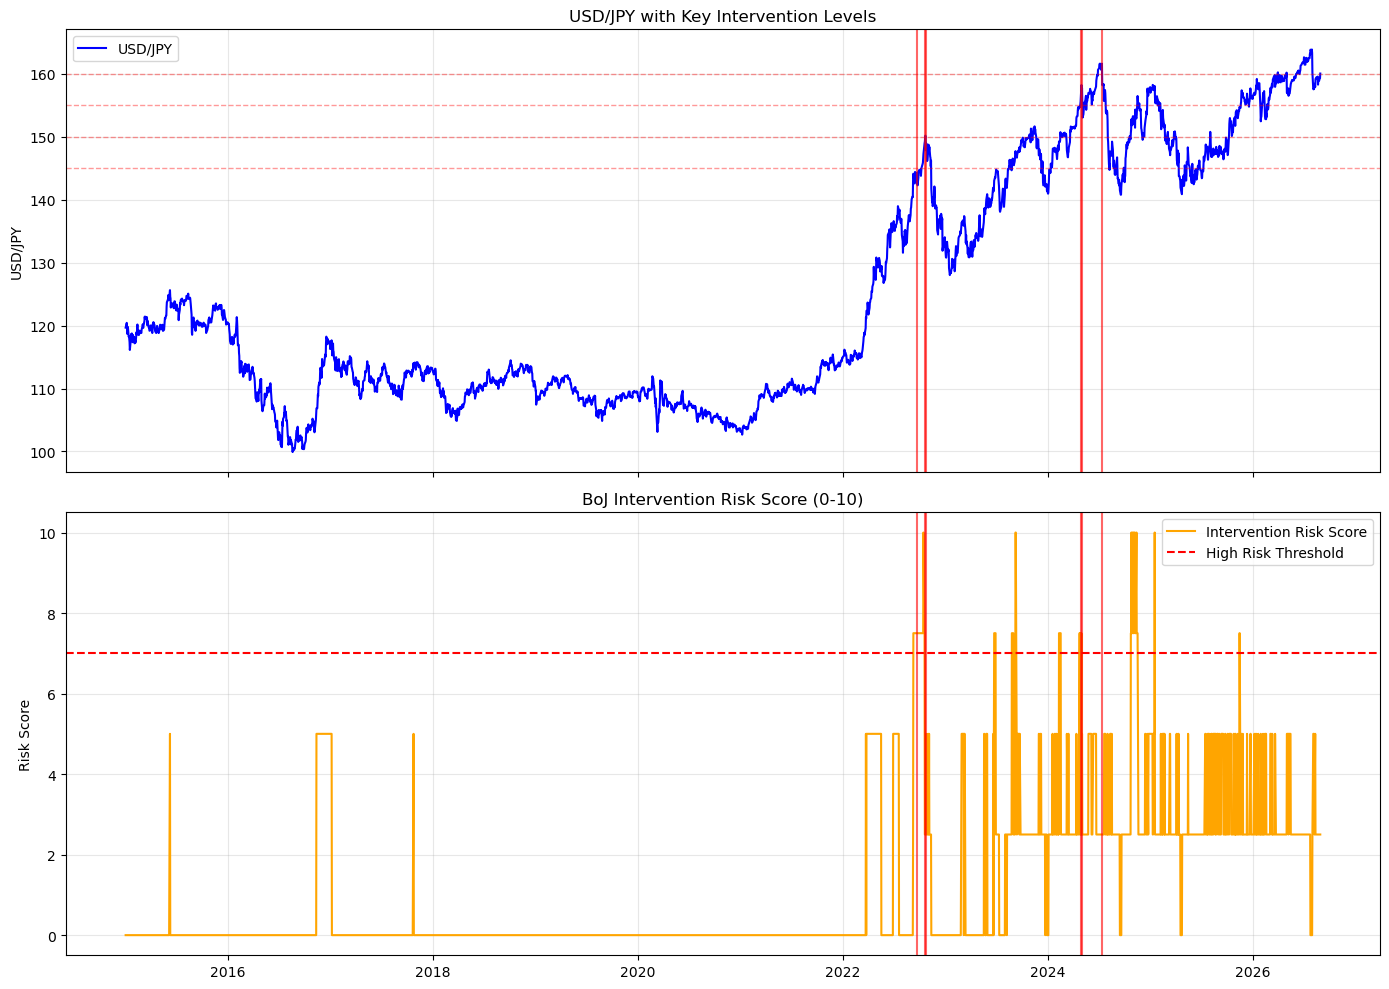

In [7]:
# Intervention Risk Signal for USD/JPY
# Based on: 30-day rate of change and distance from key levels

usdjpy = fx["USDJPY"].copy()

# 30-day percentage change — rapid appreciation = intervention risk
usdjpy_roc = usdjpy.pct_change(30) * 100

# Key psychological levels where BoJ has historically intervened
intervention_levels = [145, 150, 155, 160]

# Intervention risk score
# High when: USD/JPY has risen fast AND is near a key level
risk_score = pd.Series(0.0, index=usdjpy.index)

for level in intervention_levels:
    # Within 2% of a key level
    near_level = (abs(usdjpy - level) / level) < 0.02
    risk_score += near_level.astype(int)

# Add momentum component — rising fast increases risk
risk_score += (usdjpy_roc > 5).astype(int) * 2  # +2 if risen more than 5% in 30 days

# Normalise to 0-10 scale
risk_score = (risk_score / risk_score.max()) * 10

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

ax1.plot(usdjpy, color="blue", label="USD/JPY")
for level in intervention_levels:
    ax1.axhline(y=level, color="red", linestyle="--", alpha=0.4, linewidth=1)
for date in boj_interventions:
    ax1.axvline(x=date, color="red", linestyle="-", alpha=0.6, linewidth=1.5)
ax1.set_title("USD/JPY with Key Intervention Levels")
ax1.set_ylabel("USD/JPY")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(risk_score, color="orange", label="Intervention Risk Score")
ax2.axhline(y=7, color="red", linestyle="--", label="High Risk Threshold")
for date in boj_interventions:
    ax2.axvline(x=date, color="red", linestyle="-", alpha=0.6, linewidth=1.5)
ax2.set_title("BoJ Intervention Risk Score (0-10)")
ax2.set_ylabel("Risk Score")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

--- BoJ Intervention Signal Strategy ---
Sharpe Ratio:  0.30
Max Drawdown:  -2.36%
Win Rate:      57.14%


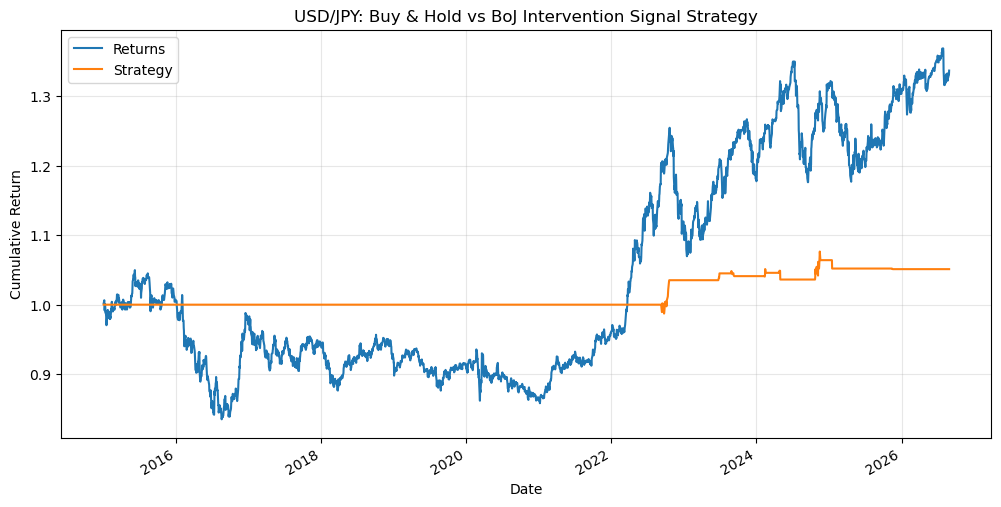

In [8]:
# Generate trade signals based on intervention risk
signals = pd.DataFrame(index=fx.index)
signals["USDJPY"] = fx["USDJPY"]
signals["Risk_Score"] = risk_score

# Signal: short USD/JPY when intervention risk is high (score > 7)
# i.e. sell USD, buy JPY anticipating BoJ intervention
signals["Signal"] = 0
signals.loc[signals["Risk_Score"] > 7, "Signal"] = -1  # Short USD/JPY

# Calculate returns
signals["Returns"] = fx["USDJPY"].pct_change()
signals["Strategy"] = signals["Signal"].shift(1) * signals["Returns"] * -1

# Risk metrics
strategy_returns = signals["Strategy"].dropna()
sharpe = (strategy_returns.mean() / strategy_returns.std()) * np.sqrt(252)

cumulative = (1 + signals["Strategy"]).cumprod()
rolling_max = cumulative.cummax()
drawdown = (cumulative - rolling_max) / rolling_max
max_drawdown = drawdown.min()

wins = (strategy_returns > 0).sum()
total = (strategy_returns != 0).sum()
win_rate = wins / total

print("--- BoJ Intervention Signal Strategy ---")
print(f"Sharpe Ratio:  {sharpe:.2f}")
print(f"Max Drawdown:  {max_drawdown:.2%}")
print(f"Win Rate:      {win_rate:.2%}")

# Plot
(1 + signals[["Returns", "Strategy"]]).cumprod().plot(
    title="USD/JPY: Buy & Hold vs BoJ Intervention Signal Strategy",
    figsize=(12, 6)
)
plt.ylabel("Cumulative Return")
plt.grid(True, alpha=0.3)
plt.show()

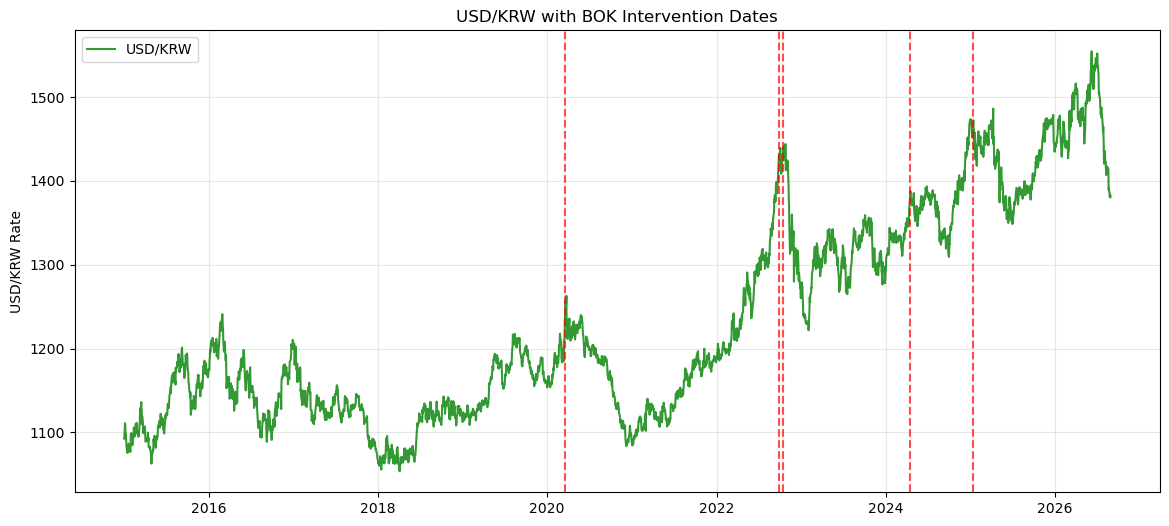

In [9]:
# BOK (Bank of Korea) Intervention Events on USD/KRW
# Major risk-off episodes where BOK sold USD to defend KRW
bok_interventions = [
    "2020-03-19",  # COVID crash - KRW hit 1285
    "2022-09-26",  # Fed hiking cycle peak fear
    "2022-10-14",  # Follow up intervention
    "2024-04-16",  # Middle East tensions spike
    "2025-01-13",  # Trump tariff fears
]

bok_interventions = [pd.Timestamp(d) for d in bok_interventions]

# Plot USD/KRW with intervention dates
plt.figure(figsize=(14, 6))
plt.plot(fx["USDKRW"], label="USD/KRW", color="green", alpha=0.8)

for date in bok_interventions:
    plt.axvline(x=date, color="red", linestyle="--", alpha=0.7, linewidth=1.5)

plt.title("USD/KRW with BOK Intervention Dates")
plt.ylabel("USD/KRW Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

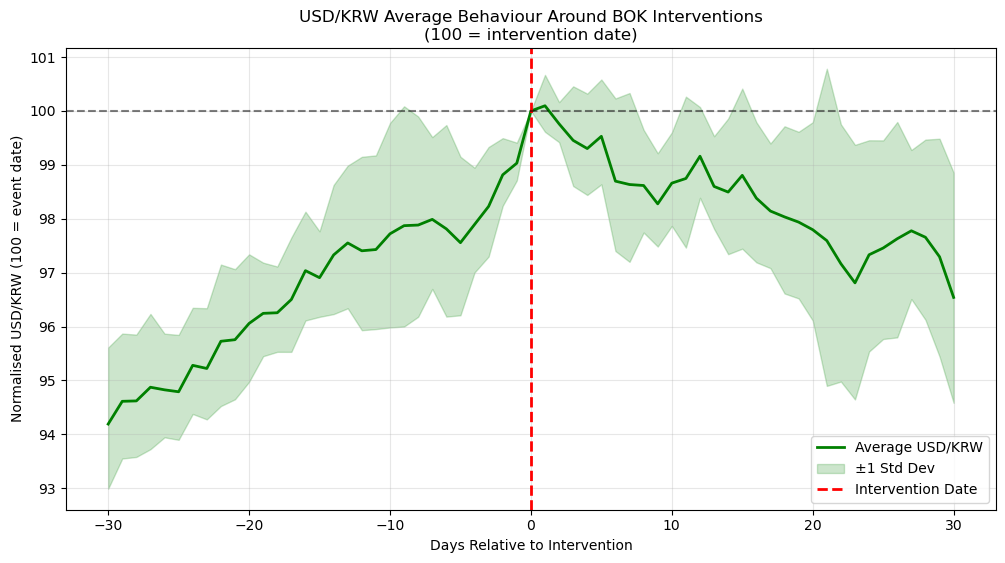

In [10]:
# Event study on USD/KRW around BOK interventions
krw_study = event_study(fx["USDKRW"], bok_interventions, window=30)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(krw_study["mean"], color="green", label="Average USD/KRW", linewidth=2)
plt.fill_between(krw_study.index,
                 krw_study["lower"],
                 krw_study["upper"],
                 alpha=0.2, color="green", label="±1 Std Dev")
plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Intervention Date")
plt.axhline(y=100, color="black", linestyle="--", alpha=0.5)
plt.title("USD/KRW Average Behaviour Around BOK Interventions\n(100 = intervention date)")
plt.xlabel("Days Relative to Intervention")
plt.ylabel("Normalised USD/KRW (100 = event date)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

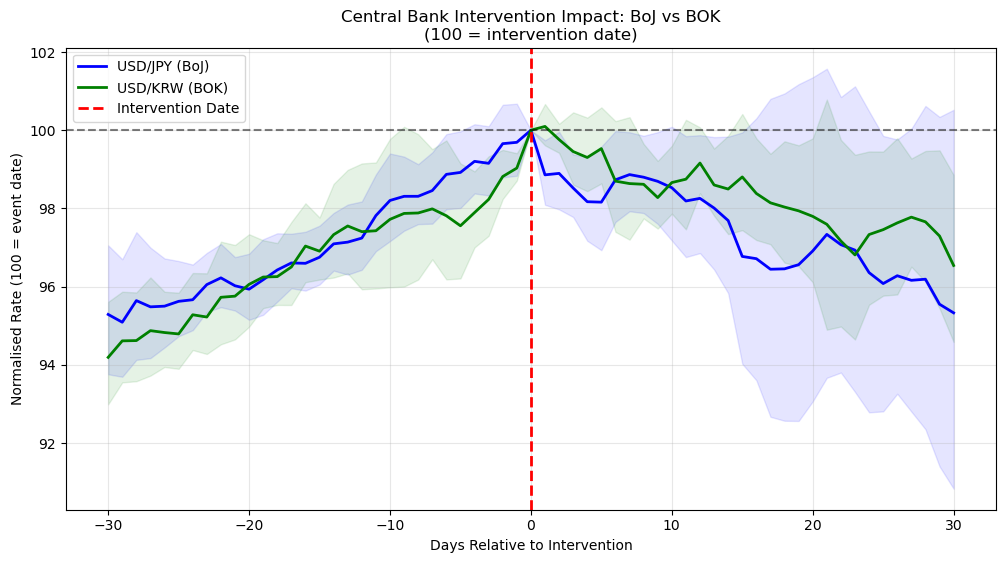

In [11]:
# Direct comparison of JPY vs KRW intervention impact
plt.figure(figsize=(12, 6))

plt.plot(usdjpy_study["mean"], color="blue", label="USD/JPY (BoJ)", linewidth=2)
plt.fill_between(usdjpy_study.index,
                 usdjpy_study["lower"],
                 usdjpy_study["upper"],
                 alpha=0.1, color="blue")

plt.plot(krw_study["mean"], color="green", label="USD/KRW (BOK)", linewidth=2)
plt.fill_between(krw_study.index,
                 krw_study["lower"],
                 krw_study["upper"],
                 alpha=0.1, color="green")

plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="Intervention Date")
plt.axhline(y=100, color="black", linestyle="--", alpha=0.5)
plt.title("Central Bank Intervention Impact: BoJ vs BOK\n(100 = intervention date)")
plt.xlabel("Days Relative to Intervention")
plt.ylabel("Normalised Rate (100 = event date)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

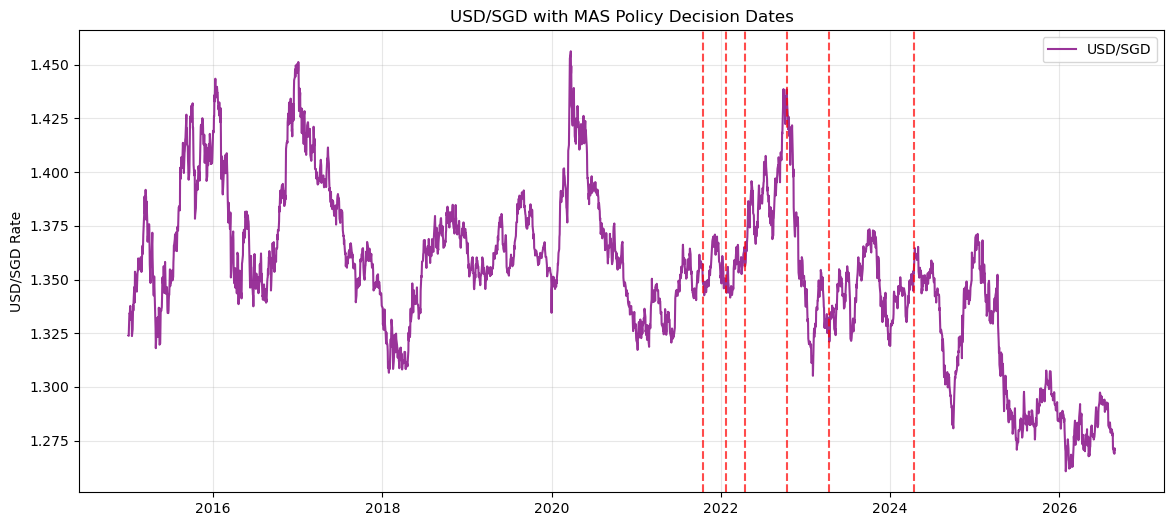

In [12]:
# MAS (Monetary Authority of Singapore) Policy Events
# MAS adjusts SGD policy band at scheduled meetings - twice yearly
mas_events = [
    "2021-10-14",  # MAS tightened - widened appreciation slope
    "2022-01-25",  # Emergency tightening - rare off cycle move
    "2022-04-14",  # Further tightening
    "2022-10-14",  # Continued tightening
    "2023-04-14",  # Held - signalled peak
    "2024-04-12",  # Easing cycle begins
]

mas_events = [pd.Timestamp(d) for d in mas_events]

# Plot USD/SGD with MAS policy events
plt.figure(figsize=(14, 6))
plt.plot(fx["USDSGD"], label="USD/SGD", color="purple", alpha=0.8)

for date in mas_events:
    plt.axvline(x=date, color="red", linestyle="--", alpha=0.7, linewidth=1.5)

plt.title("USD/SGD with MAS Policy Decision Dates")
plt.ylabel("USD/SGD Rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

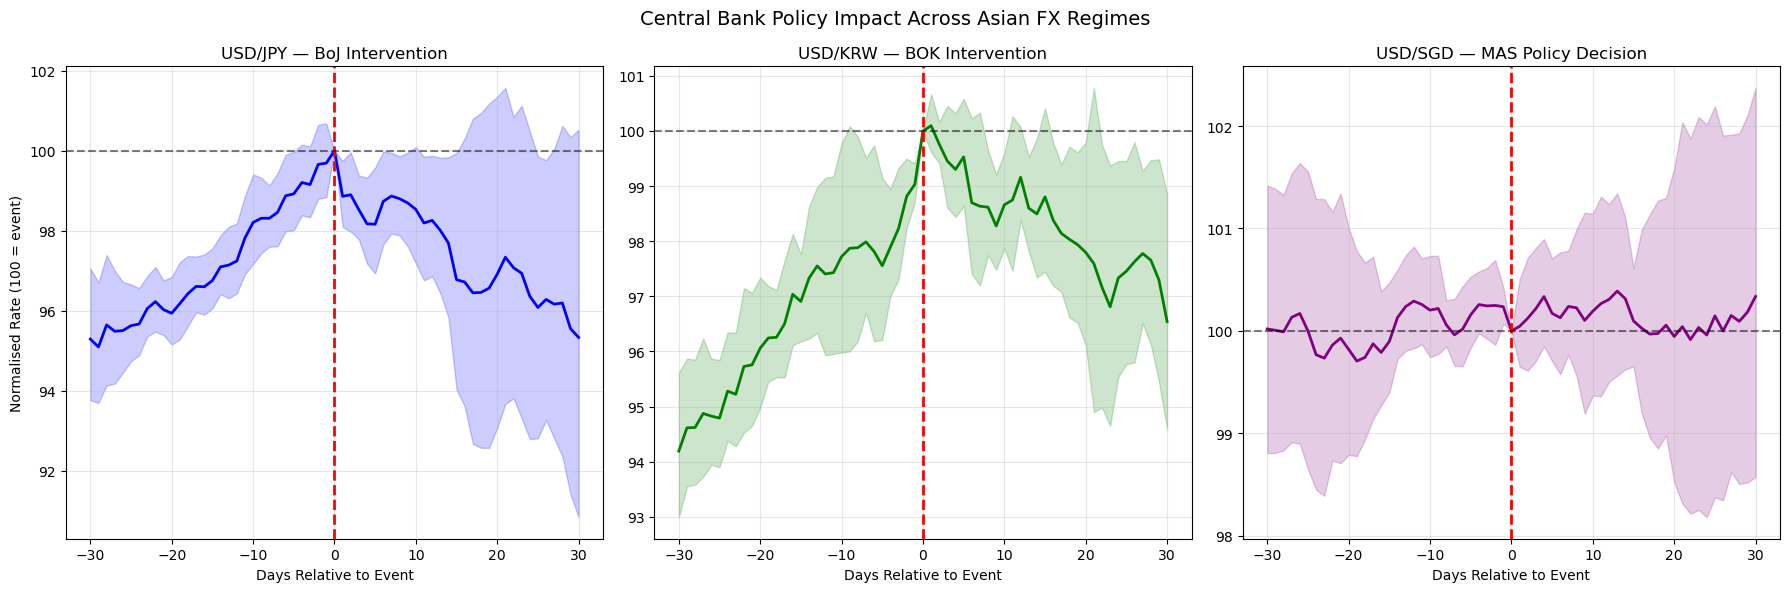

In [13]:
# Event study on USD/SGD around MAS policy decisions
sgd_study = event_study(fx["USDSGD"], mas_events, window=30)

# Plot all three event studies together
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

# JPY
axes[0].plot(usdjpy_study["mean"], color="blue", linewidth=2)
axes[0].fill_between(usdjpy_study.index,
                     usdjpy_study["lower"],
                     usdjpy_study["upper"],
                     alpha=0.2, color="blue")
axes[0].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[0].axhline(y=100, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("USD/JPY — BoJ Intervention")
axes[0].set_xlabel("Days Relative to Event")
axes[0].set_ylabel("Normalised Rate (100 = event)")
axes[0].grid(True, alpha=0.3)

# KRW
axes[1].plot(krw_study["mean"], color="green", linewidth=2)
axes[1].fill_between(krw_study.index,
                     krw_study["lower"],
                     krw_study["upper"],
                     alpha=0.2, color="green")
axes[1].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[1].axhline(y=100, color="black", linestyle="--", alpha=0.5)
axes[1].set_title("USD/KRW — BOK Intervention")
axes[1].set_xlabel("Days Relative to Event")
axes[1].grid(True, alpha=0.3)

# SGD
axes[2].plot(sgd_study["mean"], color="purple", linewidth=2)
axes[2].fill_between(sgd_study.index,
                     sgd_study["lower"],
                     sgd_study["upper"],
                     alpha=0.2, color="purple")
axes[2].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[2].axhline(y=100, color="black", linestyle="--", alpha=0.5)
axes[2].set_title("USD/SGD — MAS Policy Decision")
axes[2].set_xlabel("Days Relative to Event")
axes[2].grid(True, alpha=0.3)

plt.suptitle("Central Bank Policy Impact Across Asian FX Regimes", fontsize=14)
plt.tight_layout()
plt.show()

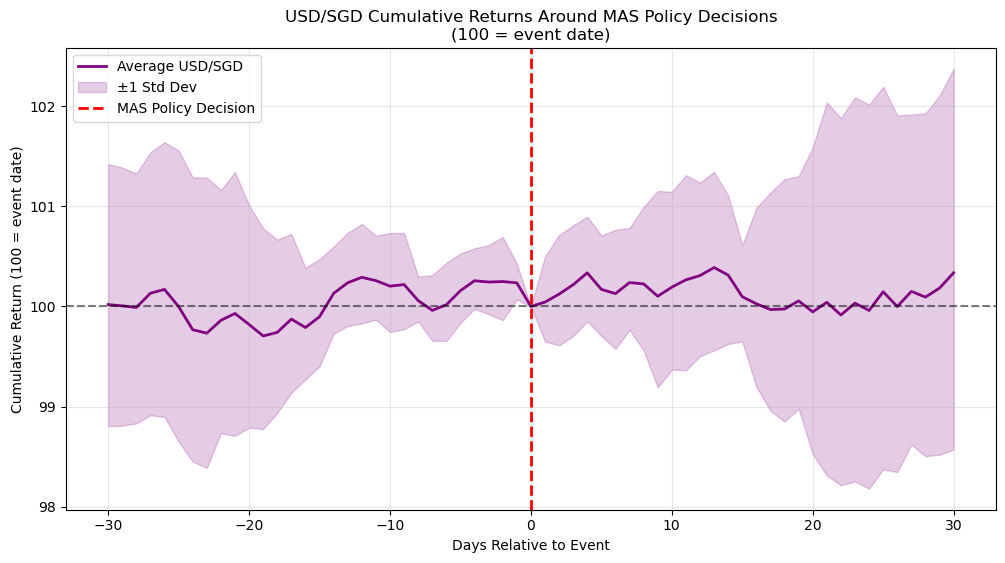

In [14]:
# Fix SGD event study — use returns instead of levels
def event_study_returns(price_series, event_dates, window=30):
    """
    Event study using cumulative returns instead of price levels.
    Better for regime-shift events like MAS policy changes.
    """
    results = []
    daily_returns = price_series.pct_change()
    
    for date in event_dates:
        try:
            idx = price_series.index.get_indexer([date], method="nearest")[0]
        except:
            continue
        
        start = max(0, idx - window)
        end = min(len(price_series), idx + window + 1)
        
        window_returns = daily_returns.iloc[start:end]
        
        # Cumulative returns relative to event date
        cum_returns = (1 + window_returns).cumprod()
        event_level = cum_returns.iloc[idx - start]
        cum_returns = (cum_returns / event_level) * 100
        
        relative_days = list(range(-(idx - start), end - idx))
        cum_returns.index = relative_days[:len(cum_returns)]
        
        results.append(cum_returns)
    
    df = pd.DataFrame(results).T
    df["mean"] = df.mean(axis=1)
    df["upper"] = df.mean(axis=1) + df.std(axis=1)
    df["lower"] = df.mean(axis=1) - df.std(axis=1)
    
    return df

# Rerun SGD study with returns-based approach
sgd_study_returns = event_study_returns(fx["USDSGD"], mas_events, window=30)

# Plot
plt.figure(figsize=(12, 6))
plt.plot(sgd_study_returns["mean"], color="purple", linewidth=2, label="Average USD/SGD")
plt.fill_between(sgd_study_returns.index,
                 sgd_study_returns["lower"],
                 sgd_study_returns["upper"],
                 alpha=0.2, color="purple", label="±1 Std Dev")
plt.axvline(x=0, color="red", linestyle="--", linewidth=2, label="MAS Policy Decision")
plt.axhline(y=100, color="black", linestyle="--", alpha=0.5)
plt.title("USD/SGD Cumulative Returns Around MAS Policy Decisions\n(100 = event date)")
plt.xlabel("Days Relative to Event")
plt.ylabel("Cumulative Return (100 = event date)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

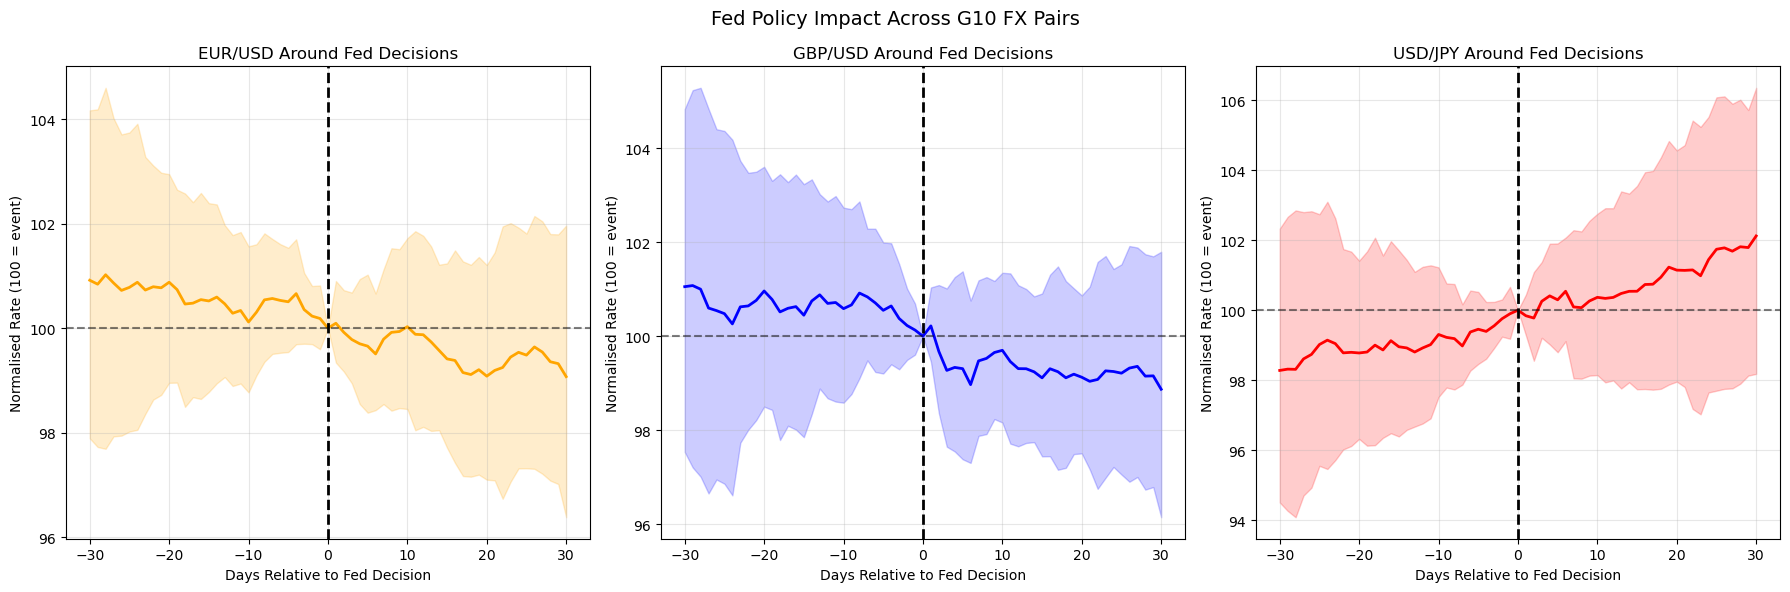

In [15]:
# Major Fed policy pivot dates
fed_events = [
    "2022-03-16",  # First hike of the cycle - 25bps
    "2022-05-04",  # 50bps hike
    "2022-06-15",  # 75bps hike - shocked markets
    "2022-07-27",  # 75bps hike
    "2022-09-21",  # 75bps hike
    "2022-11-02",  # 75bps hike
    "2022-12-14",  # 50bps - first slowdown signal
    "2023-02-01",  # 25bps - further slowdown
    "2023-07-26",  # Last hike of cycle
    "2023-09-20",  # Hold - peak rates confirmed
    "2024-09-18",  # First cut - 50bps
    "2024-11-07",  # 25bps cut
    "2024-12-18",  # 25bps cut
]

fed_events = [pd.Timestamp(d) for d in fed_events]

# Run event studies on EUR/USD and GBP/USD around Fed decisions
eurusd_fed_study = event_study(fx["EURUSD"], fed_events, window=30)
gbpusd_fed_study = event_study(fx["GBPUSD"], fed_events, window=30)
usdjpy_fed_study = event_study(fx["USDJPY"], fed_events, window=30)

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, study, pair, color in zip(
    axes,
    [eurusd_fed_study, gbpusd_fed_study, usdjpy_fed_study],
    ["EUR/USD", "GBP/USD", "USD/JPY"],
    ["orange", "blue", "red"]
):
    ax.plot(study["mean"], color=color, linewidth=2)
    ax.fill_between(study.index,
                    study["lower"],
                    study["upper"],
                    alpha=0.2, color=color)
    ax.axvline(x=0, color="black", linestyle="--", linewidth=2)
    ax.axhline(y=100, color="black", linestyle="--", alpha=0.5)
    ax.set_title(f"{pair} Around Fed Decisions")
    ax.set_xlabel("Days Relative to Fed Decision")
    ax.set_ylabel("Normalised Rate (100 = event)")
    ax.grid(True, alpha=0.3)

plt.suptitle("Fed Policy Impact Across G10 FX Pairs", fontsize=14)
plt.tight_layout()
plt.show()

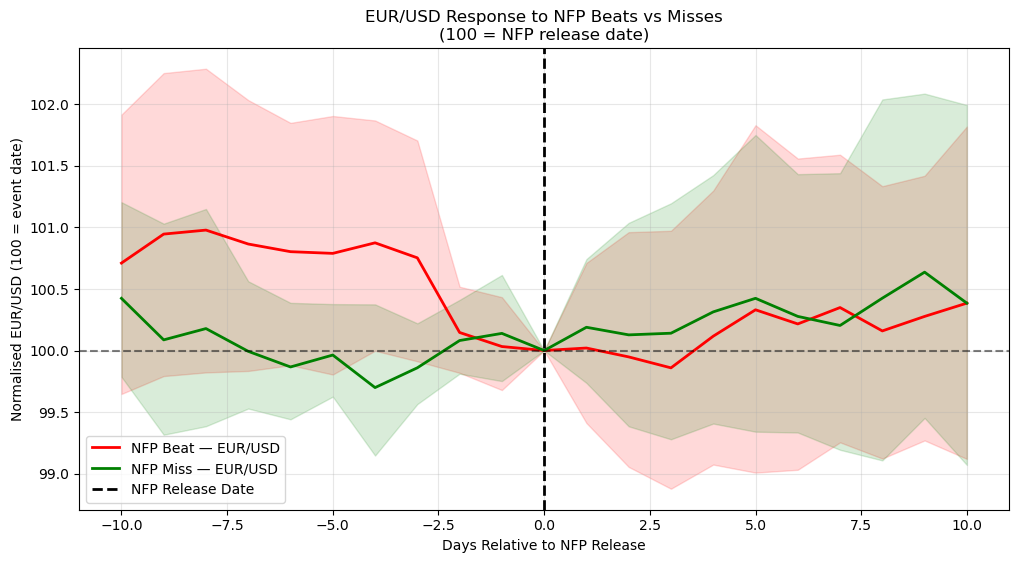

In [16]:
# Major NFP surprise dates
# These are dates where NFP significantly beat or missed expectations
nfp_beats = [
    "2021-07-02",   # +850k vs +700k expected - massive beat
    "2022-01-07",   # +199k vs +400k expected - actually a miss
    "2022-07-08",   # +372k vs +268k expected - beat
    "2023-01-06",   # +223k vs +200k expected - beat
    "2023-06-02",   # +339k vs +190k expected - massive beat
    "2024-01-05",   # +216k vs +170k expected - beat
    "2024-06-07",   # +272k vs +185k expected - massive beat
]

nfp_misses = [
    "2021-04-02",   # +266k vs +1000k expected - massive miss
    "2022-04-01",   # +431k vs +490k expected - miss
    "2023-04-07",   # +236k vs +239k expected - slight miss
    "2024-08-02",   # +114k vs +175k expected - big miss, recession fears
]

nfp_beats = [pd.Timestamp(d) for d in nfp_beats]
nfp_misses = [pd.Timestamp(d) for d in nfp_misses]

# Event studies
eurusd_beat_study = event_study(fx["EURUSD"], nfp_beats, window=10)
eurusd_miss_study = event_study(fx["EURUSD"], nfp_misses, window=10)

# Plot beats vs misses on EUR/USD
plt.figure(figsize=(12, 6))
plt.plot(eurusd_beat_study["mean"], color="red", linewidth=2, label="NFP Beat — EUR/USD")
plt.fill_between(eurusd_beat_study.index,
                 eurusd_beat_study["lower"],
                 eurusd_beat_study["upper"],
                 alpha=0.15, color="red")

plt.plot(eurusd_miss_study["mean"], color="green", linewidth=2, label="NFP Miss — EUR/USD")
plt.fill_between(eurusd_miss_study.index,
                 eurusd_miss_study["lower"],
                 eurusd_miss_study["upper"],
                 alpha=0.15, color="green")

plt.axvline(x=0, color="black", linestyle="--", linewidth=2, label="NFP Release Date")
plt.axhline(y=100, color="black", linestyle="--", alpha=0.5)
plt.title("EUR/USD Response to NFP Beats vs Misses\n(100 = NFP release date)")
plt.xlabel("Days Relative to NFP Release")
plt.ylabel("Normalised EUR/USD (100 = event date)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
# Master Signal Dashboard
# Combines intervention risk, Fed positioning, and NFP signals

today = fx.index[-1]
print(f"Signal Dashboard as of {today.date()}\n")
print("=" * 50)

# 1 - USD/JPY Intervention Risk
current_risk = risk_score.iloc[-1]
usdjpy_current = fx["USDJPY"].iloc[-1]
usdjpy_roc_current = usdjpy_roc.iloc[-1]

print("\n📊 USD/JPY — BoJ Intervention Risk")
print(f"   Current Rate:     {usdjpy_current:.2f}")
print(f"   30-day Change:    {usdjpy_roc_current:.2f}%")
print(f"   Risk Score:       {current_risk:.1f}/10")
if current_risk > 7:
    print("   ⚠️  SIGNAL: HIGH intervention risk — consider SHORT USD/JPY")
elif current_risk > 4:
    print("   ⚡ SIGNAL: MODERATE intervention risk — monitor closely")
else:
    print("   ✅ SIGNAL: LOW intervention risk — no action")

# 2 - EUR/USD momentum
eurusd_current = fx["EURUSD"].iloc[-1]
eurusd_roc = fx["EURUSD"].pct_change(30).iloc[-1] * 100
print("\n📊 EUR/USD — Momentum Signal")
print(f"   Current Rate:     {eurusd_current:.4f}")
print(f"   30-day Change:    {eurusd_roc:.2f}%")
if eurusd_roc > 2:
    print("   ⚡ SIGNAL: EUR momentum positive — dollar weakening trend")
elif eurusd_roc < -2:
    print("   ⚡ SIGNAL: EUR momentum negative — dollar strengthening trend")
else:
    print("   ✅ SIGNAL: EUR/USD in neutral range — no strong signal")

# 3 - USD/KRW Risk
usdkrw_current = fx["USDKRW"].iloc[-1]
usdkrw_roc = fx["USDKRW"].pct_change(30).iloc[-1] * 100
print("\n📊 USD/KRW — BOK Intervention Risk")
print(f"   Current Rate:     {usdkrw_current:.2f}")
print(f"   30-day Change:    {usdkrw_roc:.2f}%")
if usdkrw_roc > 3:
    print("   ⚠️  SIGNAL: KRW depreciation pressure — BOK intervention risk elevated")
elif usdkrw_roc < -3:
    print("   ✅ SIGNAL: KRW strengthening — no intervention risk")
else:
    print("   ✅ SIGNAL: USD/KRW stable — no action")

# 4 - USD/SGD
usdsgd_current = fx["USDSGD"].iloc[-1]
usdsgd_roc = fx["USDSGD"].pct_change(30).iloc[-1] * 100
print("\n📊 USD/SGD — MAS Policy Signal")
print(f"   Current Rate:     {usdsgd_current:.4f}")
print(f"   30-day Change:    {usdsgd_roc:.2f}%")
if usdsgd_roc > 1.5:
    print("   ⚠️  SIGNAL: SGD weakening — MAS may tighten band")
elif usdsgd_roc < -1.5:
    print("   ✅ SIGNAL: SGD strengthening — MAS easing bias")
else:
    print("   ✅ SIGNAL: USD/SGD within normal range")

print("\n" + "=" * 50)
print("Next key event: Watch Fed minutes and next NFP release")


Signal Dashboard as of 2026-08-28


📊 USD/JPY — BoJ Intervention Risk
   Current Rate:     160.04
   30-day Change:    -1.44%
   Risk Score:       2.5/10
   ✅ SIGNAL: LOW intervention risk — no action

📊 EUR/USD — Momentum Signal
   Current Rate:     1.1587
   30-day Change:    1.25%
   ✅ SIGNAL: EUR/USD in neutral range — no strong signal

📊 USD/KRW — BOK Intervention Risk
   Current Rate:     1380.45
   30-day Change:    -6.65%
   ✅ SIGNAL: KRW strengthening — no intervention risk

📊 USD/SGD — MAS Policy Signal
   Current Rate:     1.2708
   30-day Change:    -1.49%
   ✅ SIGNAL: USD/SGD within normal range

Next key event: Watch Fed minutes and next NFP release
